In [ ]:
from functools import partial
from typing import Union

import os

# os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'false'
# os.environ['JAX_PLATFORM_NAME'] = 'cpu'
# os.environ['JAX_PLATFORMS']='cpu'

import chex
import jax
import jax.numpy as jnp
from flax.training.train_state import TrainState  # Useful dataclass to keep train state
from jax.tree import map as tree_map
from tqdm import tqdm

import sys
sys.path.append('../../utils')
sys.path.append('../../data')
sys.path.append('../../models')

from cg import conjugate_gradient
from data_utils import batch_data
from jacobian_tools import flatten_jacobian
from model_utils import create_train_state
from MLP import MLP_1D
from plotting import plot_results
from matplotlib import pyplot as plt
jax.config.update("jax_enable_x64", True)
jax.config.update('jax_default_matmul_precision', 'highest')

from run_exp import *


In [ ]:
# Create a simple 2D discontinuous function for testing
n = 40
xx = jnp.linspace(0, 1, n)
X, Y = jnp.meshgrid(xx, xx)
x = jnp.vstack((X.flatten(), Y.flatten())).T

# Define a discontinuous function
def discontinuous_function(x):
    # Example: Discontinuous at the line x + y = 0.5
    return jnp.where(x[:, 0] + x[:, 1] < 0.5, 1.0, 0.0)

def complicated_discontinuous_function(x):
    # Define multiple regions with different values
    return jnp.where(
        x[:, 0] + x[:, 1] < 0.5, 1.0,  # Region 1
        jnp.where(
           x[:, 0] + x[:, 1] > 1.5, 2.0,  # Region 2
            jnp.where(
                (x[:, 0] < 0.5) & (x[:, 1] >= 0.5), 0.75,  # Region 3
                0.0
            )
        )
    )

# Apply the function to the input
y = complicated_discontinuous_function(x)
y = y.reshape((-1, 1))

In [ ]:
# Plotting
Y_reshaped = y.reshape(X.shape)
plt.contourf(X, Y, Y_reshaped, levels=50, cmap='coolwarm', alpha=0.8)
plt.colorbar()
plt.show()

In [101]:
model = MLP_1D(num_layers=2,hidden_dim=80)
state = create_train_state(model, learning_rate=1e-2, 
                   optimizer='sgd', shape=jnp.array([1, 1]))

state, metrics_history_sgd = train_model(state, x, y, num_iterations=20 * 10000, obtain_matrices=False, 
                                    lm_schedule=None, batch_size=400
                                    )


  0%|          | 0/200000 [00:00<?, ?it/s]

100%|██████████| 200000/200000 [37:52<00:00, 88.00it/s]


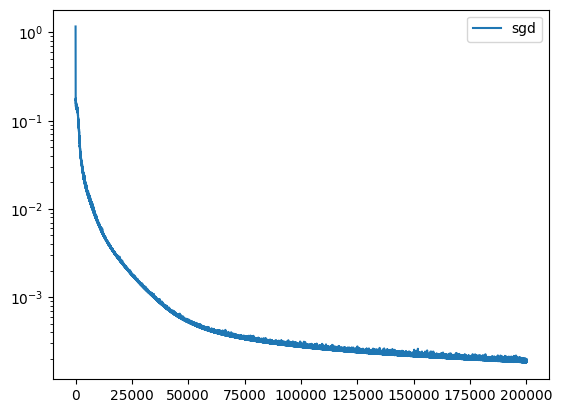

In [102]:
plt.semilogy(metrics_history_sgd['train_loss'], label='sgd')
plt.legend()
plt.show()


In [96]:
model = MLP_1D(num_layers=2,hidden_dim=80)
lm_info = PrecondData(
    method='smw',epoch=0, lamb=1e-1,
)
state = create_train_state(model, learning_rate=1e-2, 
                   optimizer='sgd', shape=jnp.array([1, 1]))

state, metrics_history_smw = train_model(state, x, y, num_iterations=10000, obtain_matrices=False, 
                                    lm_schedule=lm_info, batch_size=400
                                    )


  0%|          | 0/10000 [00:00<?, ?it/s]

Running smw


100%|██████████| 10000/10000 [17:20<00:00,  9.61it/s]


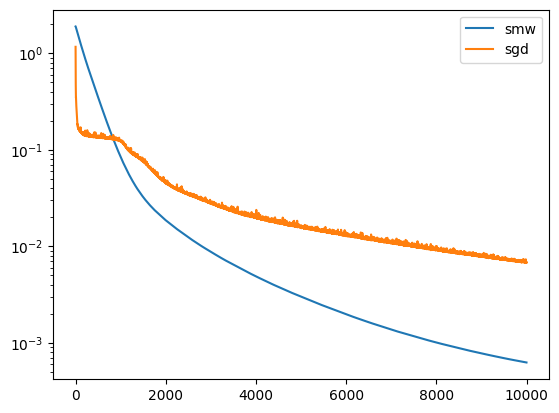

In [97]:
plt.semilogy(metrics_history_smw['train_loss'], label='smw')
plt.semilogy(metrics_history_sgd['train_loss'], label='sgd')
plt.legend()
plt.show()


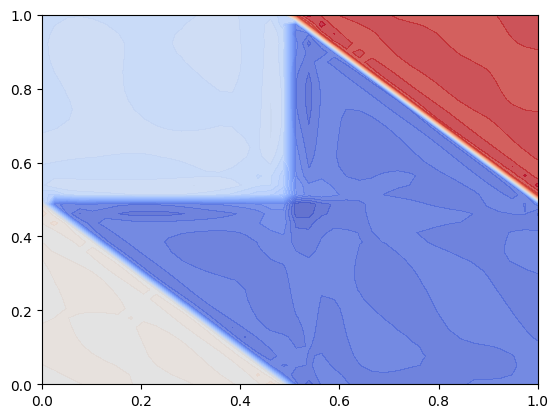

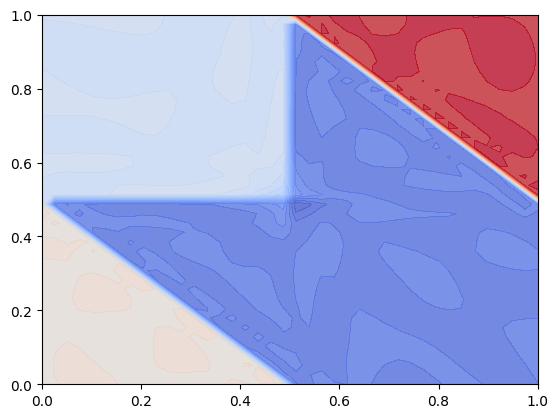

In [105]:
# Plotting
plt.contourf(X, Y, metrics_history_smw['prediction'][-1].reshape((40, 40)), levels=50, cmap='coolwarm', alpha=0.8)
# plt.contourf(X, Y, Y_reshaped, levels=50, cmap='coolwarm', alpha=0.1)

plt.show()

plt.contourf(X, Y, metrics_history_sgd['prediction'][-1].reshape((40, 40)), levels=50, cmap='coolwarm', alpha=0.8)
# plt.contourf(X, Y, Y_reshaped, levels=50, cmap='coolwarm', alpha=0.1)

plt.show()

In [99]:
model = MLP_1D(num_layers=2,hidden_dim=80)
lm_info = PrecondData(
    method='gn-exact',
)
state = create_train_state(model, learning_rate=1e-2, 
                   optimizer='sgd', shape=jnp.array([1, 1]))

state, metrics_history_gn = train_model(state, x, y, num_iterations=10000, obtain_matrices=False, 
                                    lm_schedule=lm_info, batch_size=400
                                    )


  0%|          | 0/10000 [00:00<?, ?it/s]

Running gn-exact


100%|██████████| 10000/10000 [34:36<00:00,  4.82it/s]


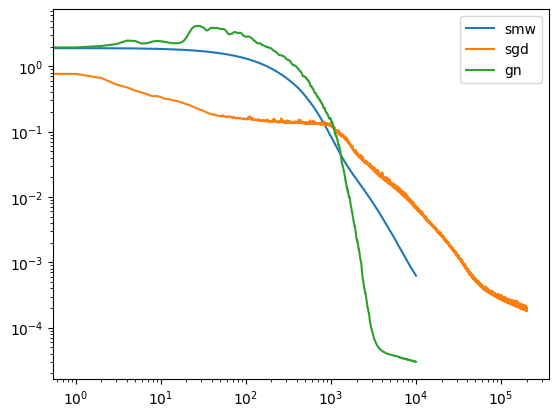

In [104]:
plt.loglog(metrics_history_smw['train_loss'], label='smw')
plt.loglog(metrics_history_sgd['train_loss'], label='sgd')
plt.loglog(metrics_history_gn['train_loss'], label='gn')
plt.legend()
plt.show()


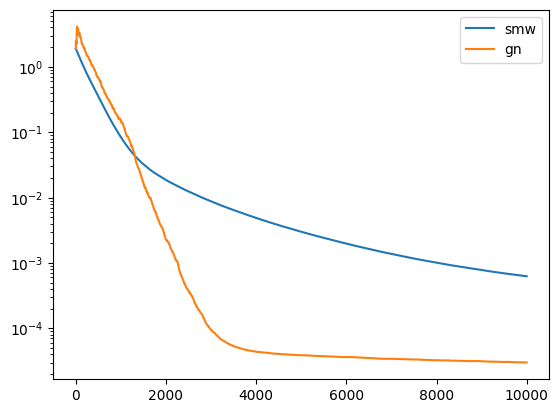

In [108]:
plt.semilogy(metrics_history_smw['train_loss'], label='smw')
# plt.semilogy(metrics_history_sgd['train_loss'], label='sgd')
plt.semilogy(metrics_history_gn['train_loss'], label='gn')
plt.legend()
plt.show()
